# Feature Relationships

## Correlation Matrix
A Correlation Matrix is a table that shows the correlation between multiple numerical variables in a dataset.
|      Correlation | Meaning                        |
| ---------------: | ------------------------------ |
|           **+1** | Perfect positive correlation   |
|   **+0.7 to +1** | Strong positive relationship   |
| **+0.3 to +0.7** | Moderate positive relationship |
|            **0** | No linear relationship         |
| **-0.3 to -0.7** | Moderate negative relationship |
|   **-0.7 to -1** | Strong negative relationship   |
|           **-1** | Perfect negative correlation   |

#### Formula

The commonly used Pearson correlation coefficient is:

$$ r = \frac{\text{Cov}(X,Y)}{\sigma_X\sigma_Y} $$

Where:

- r = correlation coefficient
- Cov(X,Y) = covariance between X and Y
- σX = standard deviation of X
- σY = standard deviation of Y

In [1]:
import pandas as pd

# Create employee dataset
data = {
    "Age": [22, 25, 28, 32, 35, 40, 45, 50],
    "Experience": [1, 3, 5, 8, 10, 15, 20, 25],
    "Salary": [25000, 32000, 40000, 55000, 65000, 80000, 100000, 120000]
}

df = pd.DataFrame(data)

# Calculate correlation matrix
correlation_matrix = df.corr()

print(correlation_matrix)

                 Age  Experience    Salary
Age         1.000000    0.995938  0.997805
Experience  0.995938    1.000000  0.998488
Salary      0.997805    0.998488  1.000000


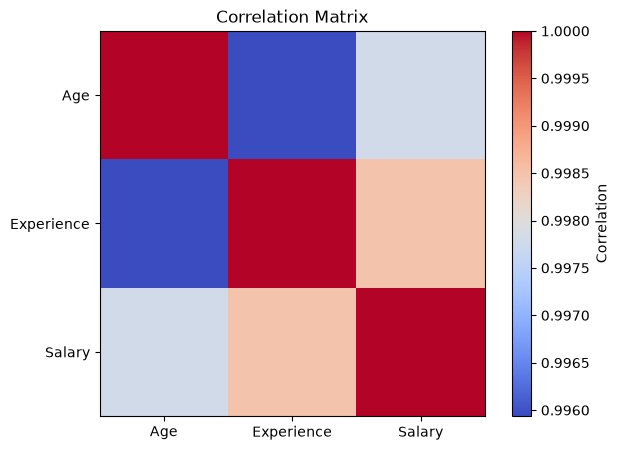

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, cmap="coolwarm")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

## Multicollinearity
Multicollinearity occurs when two or more independent variables (features) in a dataset are highly correlated with each other.
### Example

Suppose we are predicting an employee's salary using:

- Age
- Years of Experience
- Years in the Company
 | Age | Experience | Years in Company | Salary |
| --: | ---------: | ---------------: | -----: |
|  25 |          3 |                2 | 32,000 |
|  30 |          7 |                6 | 45,000 |
|  35 |         12 |               10 | 65,000 |
|  40 |         17 |               15 | 85,000 |
 

In [4]:
import pandas as pd

data = {
    "Age": [22, 25, 28, 32, 35, 40, 45, 50],
    "Experience": [1, 3, 5, 8, 10, 15, 20, 25],
    "Salary": [25000, 32000, 40000, 55000, 65000, 80000, 100000, 120000]
}

df = pd.DataFrame(data)

correlation = df.corr()

print(correlation)

                 Age  Experience    Salary
Age         1.000000    0.995938  0.997805
Experience  0.995938    1.000000  0.998488
Salary      0.997805    0.998488  1.000000


## Variance Inflation Factor (VIF)
Variance Inflation Factor (VIF) is a statistical measure used to detect multicollinearity among independent variables (features).
#### VIF Formula
$$ VIF = \frac{1}{1-R^2} $$

Where:

R² = R-squared obtained by predicting one independent variable using the other independent variables

| VIF Value | Interpretation           |
| --------: | ------------------------ |
|     **1** | No multicollinearity     |
|   **1–5** | Usually acceptable       |
|  **5–10** | Potentially high         |
|  **> 10** | Strong multicollinearity |


In [7]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = {
    "Age": [22, 25, 28, 32, 35, 40, 45, 50],
    "Experience": [1, 3, 5, 8, 10, 15, 20, 25],
    "Working_Hours": [8, 8, 9, 8, 9, 10, 9, 8]
}

df = pd.DataFrame(data)

vif_data = pd.DataFrame()

vif_data["Feature"] = df.columns

vif_data["VIF"] = [
    variance_inflation_factor(df.values, i)
    for i in range(df.shape[1])
]

print(vif_data)

         Feature         VIF
0            Age  186.868616
1     Experience  181.601902
2  Working_Hours    1.608012


## Feature Importance
Feature Importance is a technique used in Machine Learning to determine which input features contribute most to a model's predictions.
### Example

Suppose we want to predict whether a customer will leave a company (Churn).

Our features are:

- Age
- Monthly Salary
- Years of Experience
- Number of Support Calls
- Contract Type
 | Feature       | Importance |
| ------------- | ---------: |
| Contract Type |       0.35 |
| Support Calls |       0.28 |
| Salary        |       0.18 |
| Experience    |       0.12 |
| Age           |       0.07 |

 

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

data = {
    "Age": [22, 25, 28, 32, 35, 40, 45, 50],
    "Experience": [1, 3, 5, 8, 10, 15, 20, 25],
    "Working_Hours": [8, 8, 9, 8, 9, 10, 9, 8],
    "Salary": [25000, 32000, 40000, 55000, 65000, 80000, 100000, 120000]
}

df = pd.DataFrame(data)

X = df[["Age", "Experience", "Working_Hours"]]
y = df["Salary"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print(importance.sort_values(ascending=False))

Age              0.484655
Experience       0.475237
Working_Hours    0.040108
dtype: float64


## Feature Selection Basics
Feature Selection is the process of selecting the most useful features from a dataset and removing features that are unnecessary, irrelevant, or redundant.
#### Types of Feature Selection
1. Filter Methods
Features are selected using statistical measures before training the model.
Examples:
- Correlation
- Chi-Square
- ANOVA
- Mutual Information
- Variance Threshold
Example
Remove a feature with almost zero variance:
## Example

Suppose we have:

- Age
- Experience
- Salary
- Working_Hours

In [10]:
import pandas as pd

data = {
    "Age": [22, 25, 28, 32, 35, 40, 45, 50],
    "Experience": [1, 3, 5, 8, 10, 15, 20, 25],
    "Working_Hours": [8, 8, 9, 8, 9, 10, 9, 8],
    "Salary": [25000, 32000, 40000, 55000, 65000, 80000, 100000, 120000]
}

df = pd.DataFrame(data)

# Correlation with target
correlation = df.corr()["Salary"]

print(correlation)

Age              0.997805
Experience       0.998488
Working_Hours    0.239518
Salary           1.000000
Name: Salary, dtype: float64
